In [2]:
from langgraph.graph import StateGraph, START, END

C:\Users\DEV SAHU\AppData\Roaming\Python\Python313\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [6]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()

True

In [41]:
llm=ChatGroq(model="llama-3.1-8b-instant")

In [11]:
llm.invoke("hi how are you").content

"I'm just a language model, I don't have emotions or feelings like humans do, but I'm functioning properly and ready to help you with any questions or tasks you may have. How can I assist you today?"

In [30]:
def function1(state):
   llm=ChatGroq(model="llama-3.1-8b-instant")
   response = llm.invoke(state["message"]).content
   return {"message": response} 

In [13]:
function1("kya kar rhe?")

'Main ek artificial intelligence (AI) hoon, jiske paas kuch knowledge hai aur main usse apni madad ke liye upyog kar sakta hoon. Main is samay se chat kar raha hoon.\n\nMain aapko kuch information, jaise ki gharelu nuskhe, tareekh, science, aur kai anya vishayon par jaankari pradaan kar sakta hoon.\n\nAap kya chahte ki main aapke liye kuch karun?'

In [29]:
def function2(state):
    upper_str = state["message"].upper()
    return {"message":upper_str}


In [24]:
from typing import TypedDict
class State(TypedDict):
    message: str

In [31]:
workflow = StateGraph(State)

In [ ]:
workflow.add_node("fnc1",function1)
workflow.add_node("fnc2",function2)

workflow.add_edge(START,"fnc1")
# workflow.set_entry_point("fnc1") isko bhi use kar skte the
workflow.add_edge("fnc1","fnc2")
workflow.add_edge("fnc2",END)


In [33]:
app = workflow.compile()

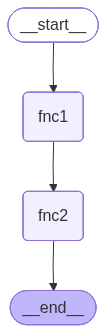

In [ ]:
from IPython.display import Image,display
# remember this code to print the graph 
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [ ]:
app.invoke({"message": "hello"})

<function dict.values()>

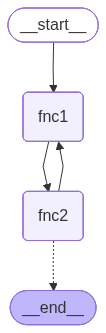

In [ ]:
cycle = StateGraph(State)
cycle.add_node("fnc1",function1)
cycle.add_edge(START,"fnc1")
cycle.add_node("fnc2",function2)
cycle.add_edge("fnc1","fnc2")
cycle.add_edge("fnc2","fnc1")

app2 = cycle.compile()
display(Image(app2.get_graph().draw_mermaid_png()))

# ek cyclic graph jioska end maine nhi banaya hai